# Tutorial: validation strategies for chaotic time series

The ESN hyperparameters ($\rho$, $\sigma_\mathrm{in}$, the Tikhonov parameter
$\lambda$) are selected by Bayesian optimization to minimize the **closed-loop**
forecast error on validation data: the network is initialized **open loop** (washout
on true data) and then run closed loop over a validation interval of $v$ steps,

$$
\epsilon(i) \;=\; \frac{1}{v} \sum_{n=i}^{i+v-1}
\big\lVert \hat{\bm{y}}_n - \bm{y}_n \big\rVert^2 ,
$$

where $\hat{\bm{y}}_n$ is the prediction fed back as the next input and
$\bm{y}_n$ the data. For a **chaotic** system this error is a fragile target:
infinitesimally close trajectories separate as $\mathrm{e}^{\Lambda t}$, so
$\epsilon(i)$ measured on a *single* interval behaves almost like a random draw —
hyperparameters that happen to score well there need not generalize to the test
data at all.

[Racca & Magri (2021)](https://doi.org/10.1016/j.neunet.2021.05.004)
([arXiv:2103.03174](https://arxiv.org/abs/2103.03174)) compare validation
strategies for ESNs on chaotic dynamics and show that the *choice of strategy* —
which data the hyperparameter search is allowed to see, and over how many
intervals the error is averaged — matters as much as the search itself. The
`EchoStateNetwork` class implements all four of their strategies:

| strategy | `validation_strategy=` | $\bm{W}_\mathrm{out}$ during validation | validation intervals |
|---|---|---|---|
| single shot (SSV) | `EchoStateNetwork._SSV` | trained once, on the data before the interval | 1 |
| walk forward (WFV) | `EchoStateNetwork._WFV` | retrained per fold on a sliding window | $K$, tiling the end |
| K-fold (KFV) | `EchoStateNetwork._KFV` | retrained per fold on all *other* data | $K$, tiling everything |
| recycle (RV) | *default* (`_RVC_Noise`) | trained **once on all the data** — the same $\bm{W}_\mathrm{out}$ used at test time | $K$, *inside* the training data |

This tutorial reproduces the paper's partition schematic (their Figure 2), then
runs a live single-reservoir comparison of the four strategies on the Lorenz 63
system of the [`EchoStateNetwork` class tutorial](01_echo_state_network.ipynb).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from echostatenetwork import EchoStateNetwork

## How each strategy partitions the data

The schematic below -- redrawn after Figure 2 of Racca & Magri (2021),
*"Robust Optimization and Validation of Echo State Networks for learning
chaotic dynamics"*, Neural Networks 142:252-268
([arXiv:2103.03174](https://arxiv.org/abs/2103.03174)) -- shows how each
strategy arranges **unused**, **training** and **validation** data along
the time series. Each bar is one **fold**, i.e. one train/validate split contributing
to the validation error the Bayesian search minimizes:

![image.png](../docs/img/validation_strategies.png)


* **bar 1** — the first fold;
* **bar 2** — the second *regular* fold: the validation interval moves
  forward by its own length $v$;
* **bar 2c** — the second fold of the *chaotic* version: the validation
  interval moves forward by **one Lyapunov time** instead. Consecutive
  intervals overlap, but chaotic divergence
  ($\mathrm{e}^{\Lambda \cdot 1\,\mathrm{LT}} = \mathrm{e}$) decorrelates
  them enough to be informative — so many more validation intervals fit in the
  same data.

In every fold the reservoir is washed out open loop on the data immediately
preceding the validation interval, then the closed-loop error is computed on
the interval.

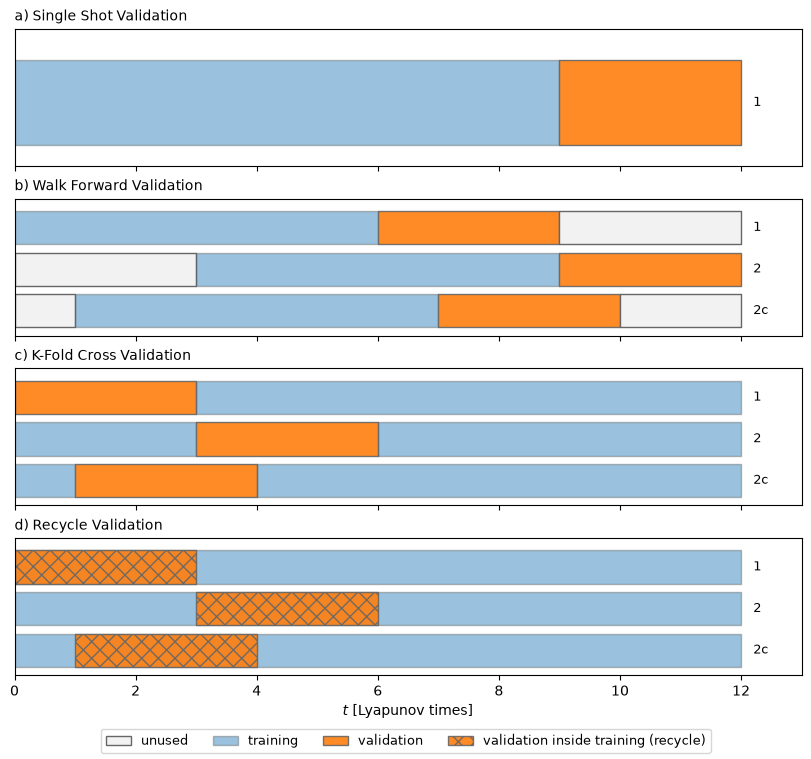

In [ ]:
# Redrawn after Figure 2 of Racca & Magri (2021): v = 3 LT validation intervals
# on a 12 LT series; the 2c bars shift the second fold by 1 LT (chaotic version)
# instead of by v.
# STYLE = {
#     'unused': dict(facecolor='0.95', edgecolor='0.4'),
#     'train': dict(facecolor='tab:blue', alpha=0.45, edgecolor='0.4'),
#     'val': dict(facecolor='tab:orange', alpha=0.9, edgecolor='0.4'),
#     'val_in': dict(facecolor='tab:orange', alpha=0.9, edgecolor='0.4', hatch='xx'),
# }
# PANELS = {
#     'a) Single Shot Validation': [
#         [('train', 0, 9), ('val', 9, 12)]],
#     'b) Walk Forward Validation': [
#         [('train', 0, 6), ('val', 6, 9), ('unused', 9, 12)],
#         [('unused', 0, 3), ('train', 3, 9), ('val', 9, 12)],
#         [('unused', 0, 1), ('train', 1, 7), ('val', 7, 10), ('unused', 10, 12)]],
#     'c) K-Fold Cross Validation': [
#         [('val', 0, 3), ('train', 3, 12)],
#         [('train', 0, 3), ('val', 3, 6), ('train', 6, 12)],
#         [('train', 0, 1), ('val', 1, 4), ('train', 4, 12)]],
#     'd) Recycle Validation': [
#         [('train', 0, 12), ('val_in', 0, 3)],
#         [('train', 0, 12), ('val_in', 3, 6)],
#         [('train', 0, 12), ('val_in', 1, 4)]],
# }

# fig, axs = plt.subplots(4, 1, figsize=(8, 7.5), sharex=True, layout='constrained')
# for ax, (title, bars) in zip(axs, PANELS.items()):
#     for row, spans in enumerate(bars):
#         for kind, t0, t1 in spans:
#             ax.broken_barh([(t0, t1 - t0)], (-row - 0.4, 0.8), **STYLE[kind])
#         ax.text(12.2, -row, '1' if row == 0 else ('2' if row == 1 else '2c'),
#                 va='center', fontsize=9)
#     ax.set_title(title, loc='left', fontsize=10)
#     ax.set(yticks=[], ylim=(-len(bars) + 0.4, 0.7), xlim=(0, 13))
# axs[-1].set_xlabel('$t$ [Lyapunov times]')
# handles = [plt.Rectangle((0, 0), 1, 1, **STYLE[k]) for k in STYLE]
# fig.legend(handles, ['unused', 'training', 'validation',
#                      'validation inside training (recycle)'],
#            loc='outside lower center', ncols=4, fontsize=9)
# plt.show()


What the figure conveys, strategy by strategy:

* **SSV** tunes the hyperparameters on **one** small interval at the end of the
  data. For a chaotic signal that single number is a poor proxy for test
  performance — this is the strategy the paper warns against.
* **WFV** distributes the validation over several intervals that tile the end
  of the data, sliding a fixed-length training window forward by $v$ per fold
  and **retraining** $\bm{W}_\mathrm{out}$ on each window. Only causal
  (past $\to$ future) splits are used.
* **KFV** goes further: the intervals tile *all* the data, and each fold trains
  on everything outside its own interval — more data per fold than WFV, but
  still one retraining per fold, and the early folds validate on data that
  precedes most of their training set.
* **RV (recycle)** trains $\bm{W}_\mathrm{out}$ **once, on all $n$ points** —
  exactly the $\bm{W}_\mathrm{out}$ that will be used at test time — and
  re-uses ("recycles") intervals *inside* the training data for closed-loop
  validation. The validation data is not held out, yet the paper shows RV
  selects hyperparameters as well as KFV at a fraction of the cost: no
  per-fold retraining, and no data sacrificed — the advantage grows on small
  datasets.
* The **2c** bars are the chaotic versions ($\mathrm{SSV}$ has none — it has
  a single interval by definition): shifting the folds by 1 LT instead of $v$
  multiplies the number of validation intervals the error is averaged over.
  In this package the fold shift is the `val_fold_step` attribute (in ESN
  steps; the default `None` keeps the regular non-overlapping folds), e.g.
  `EchoStateNetwork(..., val_fold_step=N_LYAP)` turns `_WFV`/`_KFV` into
  their chaotic versions. The package default, `_RVC_Noise`, is exactly this
  **chaotic recycle validation** (with noise regularization of the training
  inputs).

## Live comparison on the Lorenz 63 system

One reservoir, four hyperparameter searches. We deliberately mirror the paper's
small-data setup (their Sec. 4): about **12 Lyapunov times** of
washout+train+validation data, $N_\mathrm{units} = 100$, and a small Bayesian
search (15 evaluations) over $\rho \in [0.1, 1]$ and $\sigma_\mathrm{in} \in
[0.5, 5]$, with the Tikhonov parameter selected per fold from
$\{10^{-9}, 10^{-11}\}$. The reservoir ($\bm{W}$, $\bm{W}_\mathrm{in}$, i.e. the
seed) is **identical** in the four trainings — only the validation strategy
seen by the search differs. With so little data the choice has to matter.

In [3]:
T_LYAP = 1 / 0.906                    # Lyapunov time of the Lorenz 63 system
DT = 0.02
N_LYAP = int(T_LYAP / DT)             # ESN steps per Lyapunov time


def lorenz63(dt, n_lyap_times, noise_level=0.005, seed=0):
    """Noisy and clean Lorenz 63 trajectories on the attractor."""
    def rhs(t, u):
        return [10 * (u[1] - u[0]), u[0] * (28 - u[2]) - u[1],
                u[0] * u[1] - 8 / 3 * u[2]]
    t_end = (n_lyap_times + 10) * T_LYAP
    sol = solve_ivp(rhs, [0, t_end], [1., 1., 1.], t_eval=np.arange(0, t_end, dt),
                    method='RK45', rtol=1e-9)
    clean = sol.y.T[int(10 * T_LYAP / dt):]          # discard the transient
    rng = np.random.default_rng(seed)
    return clean + noise_level * clean.std(axis=0) * rng.standard_normal(clean.shape), clean


noisy, clean = lorenz63(DT, 22)
N_train, N_val = 9 * N_LYAP, 3 * N_LYAP
train_val_data = noisy[:N_train + N_val]   # 12 LT: washout + training + validation
test_clean = clean[N_train + N_val:]       # 10 LT held out for closed-loop testing
print(f'train+val: {train_val_data.shape[0]} steps, test: {test_clean.shape[0]} steps')

train+val: 660 steps, test: 556 steps


In [4]:
ESN_PARAMS = dict(N_wash=N_LYAP,           # 1 LT open-loop washout
                  N_units=100, upsample=1, seed=0,
                  t_train=N_train * DT, t_val=N_val * DT, t_test=0.,
                  N_func_evals=15, N_grid=3, noise=1e-2,
                  N_folds=3, 
                  rho_range=(.1, 1.),                              # paper Sec. 4
                  sigma_in_range=(np.log10(0.5), np.log10(5.)),    # log10 axis
                  tikh_range=[1e-9, 1e-11])

ESN_init = EchoStateNetwork(train_val_data.T, dt=DT, **ESN_PARAMS)

STRATEGIES = {'SSV (single shot)': EchoStateNetwork._SSV,
              'WFV (walk forward)': EchoStateNetwork._WFV,
              'KFV (K-fold)': EchoStateNetwork._KFV,
              'RV (recycle, default)': None}   # None -> the default _RVC_Noise

`N_folds=3` gives WFV and KFV the three non-overlapping intervals of length
`t_val` that fit in the data. The recycle strategy validates *inside* the
training data with chaotic (overlapping) fold placement, so it can afford more
intervals from the same series — we give it `N_folds=6` at its `train` call.
Each training prints its `training_summary()`.

In [5]:
esns = {}
for name, strategy in STRATEGIES.items():
    print(f'{"-" * 21} {name} {"-" * (36 - len(name))}')
    esn = ESN_init.copy()      # identical reservoir: only the validation strategy differs
    esn.train(train_val_data, plot_training=False, validation_strategy=strategy,
              **(dict(N_folds=6) if name.startswith('RV') else {}))
    esns[name] = esn

--------------------- SSV (single shot) -------------------


seed 0 	 Optimal hyperparameters: [1.0, 0.6946342849299372], 1e-11, val score: -1.6867075379319256
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=1, sigma_in=4.95, tikh=1e-11 | 1 validation fold | BHO: 15 evals over ['rho', 'sigma_in']
--------------------- WFV (walk forward) ------------------


seed 0 	 Optimal hyperparameters: [0.10545001852059734, 0.21645251275603233], 1e-09, val score: -0.5670303604728543
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=0.105, sigma_in=1.65, tikh=1e-09 | 3 validation folds | BHO: 15 evals over ['rho', 'sigma_in']
--------------------- KFV (K-fold) ------------------------


seed 0 	 Optimal hyperparameters: [0.1142787674360431, 0.18575187053654935], 1e-11, val score: -1.6515583662783488
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=0.114, sigma_in=1.53, tikh=1e-11 | 3 validation folds | BHO: 15 evals over ['rho', 'sigma_in']
--------------------- RV (recycle, default) ---------------
Modifying N_folds = 3 -> 6 at training.


seed 0 	 Optimal hyperparameters: [0.5547002809121359, 0.017174507131998362], 1e-11, val score: -1.9644468586440285
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=0.555, sigma_in=1.04, tikh=1e-11 | 6 validation folds | BHO: 15 evals over ['rho', 'sigma_in']


## Closed-loop forecasts on unseen data

Each trained ESN is initialized open loop on the same 1-Lyapunov-time washout
of (clean) test data, then run closed loop from the **same test start**. The
**predictability horizon** in each panel title is the time until the normalized
error first exceeds 0.2 (the paper's threshold), in Lyapunov times.

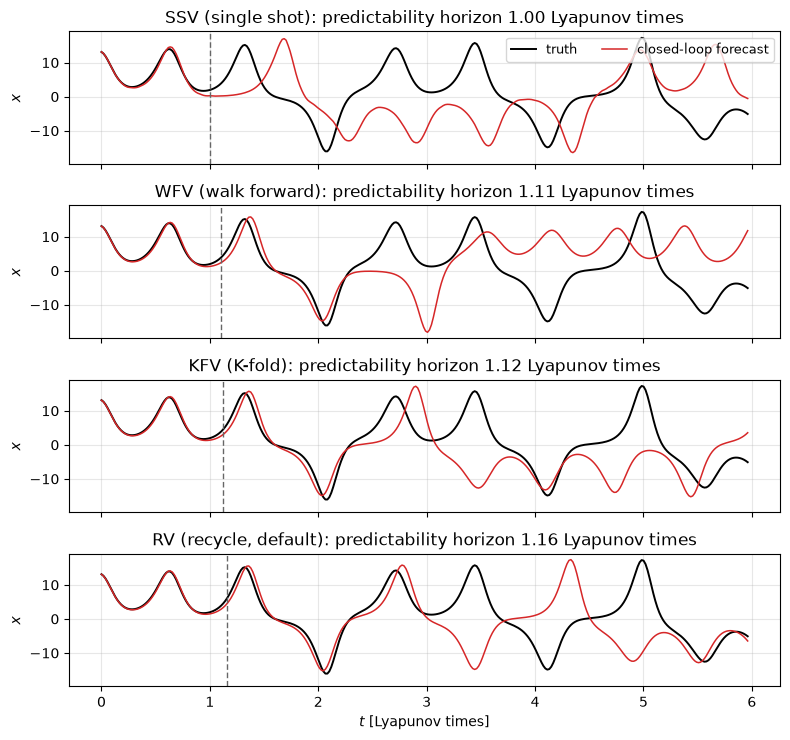

In [6]:
def closed_loop(esn, wash, n_steps):
    """Open-loop washout on true history, then an n_steps closed-loop forecast.

    The washout drives the reservoir open loop through `wash`; its last output
    (the one-step-ahead prediction of the frame after `wash`) is the first
    closed-loop input, so prediction i corresponds to the data row
    len(wash) + 1 + i — as in scripts/compare_validation_strategies.py."""
    r = np.zeros((esn.N_units, 1))
    u = np.zeros((esn.N_dim, 1))
    for u_in in wash:
        u, r = esn.step(u_in[:, None], r)
    U = []
    for _ in range(n_steps):
        u, r = esn.step(esn.outputs_to_inputs(u), r)
        U.append(u[:, 0])
    return np.array(U)


def forecast_and_horizon(esn, i0, n_fc, threshold=0.2):
    """Forecast n_fc steps from test start i0; horizon in Lyapunov times."""
    truth = test_clean[i0 + N_LYAP + 1:i0 + N_LYAP + 1 + n_fc]
    U = closed_loop(esn, test_clean[i0:i0 + N_LYAP], len(truth))
    err = np.linalg.norm((U - truth) / test_clean.std(axis=0), axis=1) / np.sqrt(3)
    above = np.flatnonzero(err > threshold)
    return U, truth, (above[0] if above.size else len(truth)) * DT / T_LYAP


n_fc = 6 * N_LYAP
t_fc = np.arange(n_fc) * DT / T_LYAP

fig, axs = plt.subplots(4, 1, sharex=True, sharey=True, figsize=(8, 7.5),
                        layout='tight')
for ax, (name, esn) in zip(axs, esns.items()):
    U, truth, h = forecast_and_horizon(esn, i0=0, n_fc=n_fc)
    ax.plot(t_fc, truth[:, 0], 'k', lw=1.4, label='truth')
    ax.plot(t_fc, U[:, 0], 'C3', lw=1.1, label='closed-loop forecast')
    ax.axvline(h, color='0.4', dashes=[4, 2], lw=1)
    ax.set(ylabel='$x$', title=f'{name}: predictability horizon {h:.2f} Lyapunov times')
    ax.grid(alpha=0.3)
axs[0].legend(ncols=2, fontsize=9, loc='upper right')
axs[-1].set(xlabel='$t$ [Lyapunov times]')
plt.show()

A single forecast is itself a single draw from the chaotic system — the honest
comparison averages the horizon over several test starts:

In [7]:
for name, esn in esns.items():
    hs = [forecast_and_horizon(esn, i0=s * 80, n_fc=n_fc)[2] for s in range(5)]
    print(f'{name:24s} mean horizon over 5 test starts: {np.mean(hs):.2f} LT  '
          + str([f'{h:.1f}' for h in hs]))

SSV (single shot)        mean horizon over 5 test starts: 0.63 LT  ['1.0', '0.5', '0.5', '0.4', '0.8']
WFV (walk forward)       mean horizon over 5 test starts: 1.80 LT  ['1.1', '3.3', '1.7', '0.5', '2.4']
KFV (K-fold)             mean horizon over 5 test starts: 1.76 LT  ['1.1', '3.2', '1.7', '0.5', '2.3']
RV (recycle, default)    mean horizon over 5 test starts: 1.80 LT  ['1.2', '3.2', '1.8', '0.5', '2.3']


## The paper's headline number: validation–test correlation

A validation strategy is only as good as the agreement between the error it
reports and the error at test time. Table 1 of Racca & Magri (2021) quantifies
this as the **Spearman correlation between validation MSE and test MSE** over
an ensemble of $50$ reservoir realizations (each with its own optimal
hyperparameters), for a short ($12$ LT) and a long ($24$ LT) dataset
(subscript $c$ = chaotic version):

| strategy | short (12 LT) | long (24 LT) |
|:---|:---:|:---:|
| SSV | 0.31 | 0.49 |
| WFV | 0.31 | 0.51 |
| WFV$_c$ | 0.50 | 0.61 |
| KFV | 0.60 | 0.70 |
| KFV$_c$ | 0.65 | 0.85 |
| RV | 0.59 | 0.67 |
| RV$_c$ | 0.62 | 0.81 |

Three consistent messages: **SSV correlates worst** with the test error; every
**chaotic version beats its regular counterpart** (more validation intervals
from the same data); and **KFV$_c$ is best, with RV$_c$ close behind at
recycle cost** — a single training, no per-fold retraining, no held-out data.

[`scripts/compare_validation_strategies.py`](../scripts/compare_validation_strategies.py)
is the runnable ensemble version of this comparison: for an ensemble of
reservoir seeds it records each member's best validation error alongside its
test MSE — the (validation, test) pairs behind this same table and the
paper's Fig. 8 validation-vs-test scatter.

## Seeded ensembles: `train(n_seeds=...)`

Everything above used one reservoir realization per strategy (`seed=0`), but
`W` and `W_in` are random draws -- Racca & Magri's tables are *ensemble*
statements precisely because a single draw can be lucky or unlucky.
`train(n_seeds=m)` trains `m` realizations of the same ESN (seeds
`base, base+1, ...`) on the same data and settings, one process each, scores
every one with the validation strategy (the BHO minimum), keeps the best
network in place, and stores all the scores in `seed_scores` for the
statistical comparison.

Selecting by validation score works: in the ensemble run of
[`scripts/compare_validation_strategies.py`](../scripts/compare_validation_strategies.py)
the kept member always lands in the ensemble's best half on *test* error,
usually the best quarter -- and recycle validation on the short dataset picked
the true best of 96 seeds.

In [8]:
esn_ens = ESN_init.copy()
esn_ens.train(train_val_data, plot_training=False, n_seeds=4, N_folds=6)  # default RV_c

print('log10 validation score per seed:',
      ', '.join(f'{s}: {v:.3f}' for s, v in esn_ens.seed_scores.items()))
hs = [forecast_and_horizon(esn_ens, i0=s * 80, n_fc=n_fc)[2] for s in range(5)]
print(f'kept network (seed {esn_ens.seed}): '
      f'mean horizon over 5 test starts {np.mean(hs):.2f} LT')

Modifying N_folds = 3 -> 6 at training.
seed 0 	 Optimal hyperparameters: [0.48774092508204236, 0.26124391817825504], 1e-09, val score: -1.9179080712341385
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=0.488, sigma_in=1.82, tikh=1e-09 | 6 validation folds | BHO: 15 evals over ['rho', 'sigma_in']
Modifying N_folds = 3 -> 6 at training.
seed 1 	 Optimal hyperparameters: [0.5968594368114074, 0.04777031226446771], 1e-09, val score: -1.6186088863032069
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=0.597, sigma_in=1.12, tikh=1e-09 | 6 validation folds | BHO: 15 evals over ['rho', 'sigma_in']
Modifying N_folds = 3 -> 6 at training.
seed 2 	 Optimal hyperparameters: [0.49058376540430426, -0.012128485141530199], 1e-11, val score: -1.6481693856381143
trained: 495+165 train+val steps, 0 test | t_train=9.9, t_val=3.3 | rho=0.491, sigma_in=0.972, tikh=1e-11 | 6 validation folds | BHO: 15 evals over ['rho', 'sigma_in']
Modifying N_folds = 3 -> 6 at